In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import optimize
from scipy.special import gammaln

In [2]:
DATA_DIR = Path("../data/CMAPSSData")
IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

COLS = ["unit", "cycle"] + [f"op_{i}" for i in range(1, 4)] + [f"s_{i}" for i in range(1, 22)]
ALL_SENSORS = [f"s_{i}" for i in range(1, 22)]
WINDOW = 15
RUL_CAP = 125
RNG = np.random.default_rng(0)

In [3]:
def load(ds):
    tr = pd.read_csv(DATA_DIR / f"train_{ds}.txt", sep=r"\s+", header=None, names=COLS, engine="python")
    te = pd.read_csv(DATA_DIR / f"test_{ds}.txt", sep=r"\s+", header=None, names=COLS, engine="python")
    rul = pd.read_csv(DATA_DIR / f"RUL_{ds}.txt", header=None, names=["RUL"]).squeeze("columns").values
    return tr, te, rul
 
 
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1).sum()
 
 
def metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "NASA_score": float(nasa_score(y_true, y_pred)),
    }
 
 
def assign_regime(df, kmeans):
    if kmeans is None:
        return np.zeros(len(df), dtype=int)
    return kmeans.predict(df[["op_1", "op_2", "op_3"]].values)
 
 
def select_informative_sensors(train_df, regime_col, thr=1e-3):
    """Keep sensors with within-regime std > thr in at least one regime."""
    kept = []
    for s in ALL_SENSORS:
        within = train_df.groupby(regime_col)[s].std().fillna(0)
        if within.max() > thr:
            kept.append(s)
    return kept
 
 
def fit_regime_stats(train_df, sensors, regime_col):
    """Return dict regime -> (mean_vec, std_vec) from train data only."""
    stats = {}
    for r, g in train_df.groupby(regime_col):
        mu = g[sensors].mean().values
        sd = g[sensors].std().replace(0, 1).values
        stats[r] = (mu, sd)
    return stats
 
 
def normalize_by_regime(df, sensors, regime_col, stats):
    out = df[sensors].values.astype(float).copy()
    r = df[regime_col].values
    for reg, (mu, sd) in stats.items():
        mask = r == reg
        if mask.any():
            out[mask] = (out[mask] - mu) / sd
    return pd.DataFrame(out, columns=[f"{s}_n" for s in sensors], index=df.index)
 
 
def build_features(df, sensors, normalized=True, stats=None, regime_col="regime"):
    if normalized:
        norm = normalize_by_regime(df, sensors, regime_col, stats)
        df = pd.concat([df[["unit", "cycle", regime_col]], norm], axis=1)
        feat_sensors = [f"{s}_n" for s in sensors]
    else:
        df = df[["unit", "cycle", regime_col] + sensors].copy()
        feat_sensors = sensors
 
    g = df.groupby("unit")[feat_sensors]
    roll = g.rolling(WINDOW, min_periods=1)
    parts = [df[["unit", "cycle", regime_col] + feat_sensors].reset_index(drop=True)]
    parts.append(roll.mean().reset_index(level=0, drop=True).add_suffix("_m").reset_index(drop=True))
    parts.append(roll.std().fillna(0).reset_index(level=0, drop=True).add_suffix("_sd").reset_index(drop=True))
 
    # Fast approximate slope: (x_t - x_{t-w+1}) / (w-1), computed per unit.
    # Equivalent up to a constant factor to the full least-squares slope over a
    # monotonically-indexed window, which is what rolling-apply(polyfit) produced.
    shifted = df.groupby("unit")[feat_sensors].shift(WINDOW - 1)
    sl = ((df[feat_sensors] - shifted) / (WINDOW - 1)).fillna(0).add_suffix("_sl").reset_index(drop=True)
    parts.append(sl)
    return pd.concat(parts, axis=1)
 
 
def run_experiment(ds, n_regimes, normalized=True, use_regime_feature=True, verbose=True):
    train_raw, test_raw, rul_true = load(ds)
 
    # ---- regime assignment ----
    if n_regimes == 1:
        km = None
        train_raw = train_raw.assign(regime=0)
        test_raw = test_raw.assign(regime=0)
    else:
        km = KMeans(n_clusters=n_regimes, n_init=10, random_state=0)
        km.fit(train_raw[["op_1", "op_2", "op_3"]].values)
        train_raw = train_raw.assign(regime=km.labels_)
        test_raw = test_raw.assign(regime=assign_regime(test_raw, km))
 
    sensors = select_informative_sensors(train_raw, "regime")
    if verbose:
        print(f"  [{ds}] {n_regimes} regime(s), {len(sensors)} informative sensors")
 
    stats = fit_regime_stats(train_raw, sensors, "regime") if normalized else None
    X_tr_df = build_features(train_raw, sensors, normalized=normalized, stats=stats)
    X_tr_df["RUL"] = (train_raw.groupby("unit").cycle.transform("max") - train_raw.cycle).clip(upper=RUL_CAP).values
 
    exclude = ["unit", "cycle", "RUL"]
    cat_features_arg = ["regime"]
    if not use_regime_feature:
        exclude.append("regime")
        cat_features_arg = None
    feature_cols = [c for c in X_tr_df.columns if c not in exclude]
 
    # 20%-of-units held-out val
    all_units = X_tr_df["unit"].unique()
    val_u = RNG.choice(all_units, size=max(20, len(all_units) // 5), replace=False)
    is_val = X_tr_df["unit"].isin(val_u).values
 
    X_tr_df["regime"] = X_tr_df["regime"].astype(int)
    X_tr = X_tr_df.loc[~is_val, feature_cols]
    y_tr = X_tr_df.loc[~is_val, "RUL"].values
    X_val = X_tr_df.loc[is_val, feature_cols]
    y_val = X_tr_df.loc[is_val, "RUL"].values
 
    model = CatBoostRegressor(
        iterations=1000, learning_rate=0.08, depth=5,
        loss_function="RMSE", eval_metric="RMSE",
        early_stopping_rounds=40, random_seed=42, verbose=False,
        cat_features=cat_features_arg,
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
 
    # Official test set: last observation per unit
    X_te_df = build_features(test_raw, sensors, normalized=normalized, stats=stats)
    X_te_df["regime"] = X_te_df["regime"].astype(int)
    last = X_te_df.groupby("unit").tail(1).sort_values("unit")
    X_te = last[feature_cols]
    preds = np.clip(model.predict(X_te), 0, None)
 
    return {
        "model": model,
        "metrics": metrics(rul_true, preds),
        "preds": preds,
        "y_true": rul_true,
        "n_features": len(feature_cols),
        "n_sensors": len(sensors),
        "feature_cols": feature_cols,
        "best_iter": model.get_best_iteration(),
    }

In [4]:
def slice_rmse(y_true, y_pred, mask):
    if mask.sum() == 0:
        return np.nan, np.nan
    e = y_pred[mask] - y_true[mask]
    return float(np.sqrt((e ** 2).mean())), float(e.mean())
 
 
def run_one(ds, cap, n_regimes=6):
    """Train CatBoost on `ds` with `cap` (use None for no cap), return test metrics."""
    train_raw, test_raw, rul_true = load(ds)
    km = KMeans(n_clusters=n_regimes, n_init=10, random_state=0).fit(
        train_raw[["op_1", "op_2", "op_3"]].values)
    train_raw = train_raw.assign(regime=km.labels_)
    test_raw = test_raw.assign(regime=km.predict(test_raw[["op_1", "op_2", "op_3"]].values))
 
    sensors = select_informative_sensors(train_raw, "regime")
    stats = fit_regime_stats(train_raw, sensors, "regime")
    Xtr = build_features(train_raw, sensors, normalized=True, stats=stats)
    Xtr["regime"] = Xtr["regime"].astype(int)
    y_raw = (train_raw.groupby("unit").cycle.transform("max") - train_raw.cycle).values.astype(float)
    ytr = y_raw if cap is None else np.minimum(y_raw, cap)
 
    fcols = [c for c in Xtr.columns if c not in ("unit", "cycle")]
    all_u = Xtr["unit"].unique()
    val_u = np.random.default_rng(0).choice(all_u, size=max(20, len(all_u) // 5), replace=False)
    is_val = Xtr["unit"].isin(val_u).values
 
    model = CatBoostRegressor(
        iterations=1000, learning_rate=0.08, depth=5,
        loss_function="RMSE", eval_metric="RMSE",
        early_stopping_rounds=40, random_seed=42, verbose=False,
        cat_features=["regime"],
    )
    model.fit(Xtr.loc[~is_val, fcols], ytr[~is_val],
              eval_set=(Xtr.loc[is_val, fcols], ytr[is_val]))
 
    Xte = build_features(test_raw, sensors, normalized=True, stats=stats)
    Xte["regime"] = Xte["regime"].astype(int)
    last = Xte.groupby("unit").tail(1).sort_values("unit")
    preds = np.clip(model.predict(last[fcols]), 0, None)
 
    low = rul_true <= 50
    mid = (rul_true > 50) & (rul_true <= 100)
    high = rul_true > 100
 
    rmse_all = float(np.sqrt(((preds - rul_true) ** 2).mean()))
    rmse_low, mean_low = slice_rmse(rul_true, preds, low)
    rmse_mid, mean_mid = slice_rmse(rul_true, preds, mid)
    rmse_high, mean_high = slice_rmse(rul_true, preds, high)
    return {
        "cap": "none" if cap is None else cap,
        "RMSE_all": rmse_all,
        "RMSE_low": rmse_low, "bias_low": mean_low,
        "RMSE_mid": rmse_mid, "bias_mid": mean_mid,
        "RMSE_high": rmse_high, "bias_high": mean_high,
        "NASA": nasa_score(rul_true, preds),
        "n_low": int(low.sum()), "n_mid": int(mid.sum()), "n_high": int(high.sum()),
        "preds": preds, "true": rul_true,
    }
 
 
caps = [100, 125, 150, 180, None]
results = {}
for ds in ["FD002", "FD004"]:
    print(f"\n=== {ds} ===")
    rows = []
    for cap in caps:
        r = run_one(ds, cap)
        rows.append(r)
        print(f"  cap={str(r['cap']):>4s}  RMSE={r['RMSE_all']:5.2f}  "
              f"low(≤50,n={r['n_low']})={r['RMSE_low']:5.2f} bias={r['bias_low']:+.1f}  "
              f"mid(n={r['n_mid']})={r['RMSE_mid']:5.2f} bias={r['bias_mid']:+.1f}  "
              f"high(>100,n={r['n_high']})={r['RMSE_high']:5.2f} bias={r['bias_high']:+.1f}  "
              f"NASA={r['NASA']:.0f}")
    results[ds] = rows


=== FD002 ===
  cap= 100  RMSE=34.66  low(≤50,n=88)=11.84 bias=+4.1  mid(n=79)=16.13 bias=-0.7  high(>100,n=92)=55.00 bias=-47.7  NASA=27073
  cap= 125  RMSE=29.12  low(≤50,n=88)=12.67 bias=+4.5  mid(n=79)=21.81 bias=+6.7  high(>100,n=92)=42.71 bias=-31.6  NASA=12920
  cap= 150  RMSE=26.96  low(≤50,n=88)=12.76 bias=+4.4  mid(n=79)=26.77 bias=+11.0  high(>100,n=92)=35.72 bias=-19.8  NASA=8612
  cap= 180  RMSE=27.45  low(≤50,n=88)=12.88 bias=+4.2  mid(n=79)=31.21 bias=+13.9  high(>100,n=92)=33.56 bias=-11.6  NASA=11689
  cap=none  RMSE=29.22  low(≤50,n=88)=14.70 bias=+7.8  mid(n=79)=34.17 bias=+17.0  high(>100,n=92)=34.56 bias=-5.5  NASA=18760

=== FD004 ===
  cap= 100  RMSE=36.90  low(≤50,n=80)=14.98 bias=+7.4  mid(n=68)=17.73 bias=+0.4  high(>100,n=100)=54.62 bias=-48.6  NASA=20764
  cap= 125  RMSE=29.89  low(≤50,n=80)=16.35 bias=+7.7  mid(n=68)=24.87 bias=+9.8  high(>100,n=100)=39.76 bias=-31.4  NASA=7164
  cap= 150  RMSE=27.60  low(≤50,n=80)=17.55 bias=+7.9  mid(n=68)=31.25 bias=+16

In [5]:
# ============ Summary table ============
rows_flat = []
for ds, rs in results.items():
    for r in rs:
        rows_flat.append({k: r[k] for k in ["cap", "RMSE_all", "RMSE_low", "RMSE_mid",
                                             "RMSE_high", "bias_high", "NASA"]} | {"ds": ds})
summary = pd.DataFrame(rows_flat).set_index(["ds", "cap"])
summary.to_csv("cap_sweep.csv")
print("\nSummary:")
print(summary.round(2).to_string())


Summary:
            RMSE_all  RMSE_low  RMSE_mid  RMSE_high  bias_high       NASA
ds    cap                                                                
FD002 100      34.66     11.84     16.13      55.00     -47.67   27072.90
      125      29.12     12.67     21.81      42.71     -31.57   12920.48
      150      26.96     12.76     26.77      35.72     -19.77    8611.81
      180      27.45     12.88     31.21      33.56     -11.57   11689.33
      none     29.22     14.70     34.17      34.56      -5.52   18759.92
FD004 100      36.90     14.98     17.73      54.62     -48.59   20764.30
      125      29.89     16.35     24.87      39.76     -31.44    7164.12
      150      27.60     17.55     31.25      31.29     -17.66    7847.11
      180      28.73     18.14     36.77      29.39      -6.01   15177.38
      none     38.95     20.85     48.09      42.93      13.43  286051.59


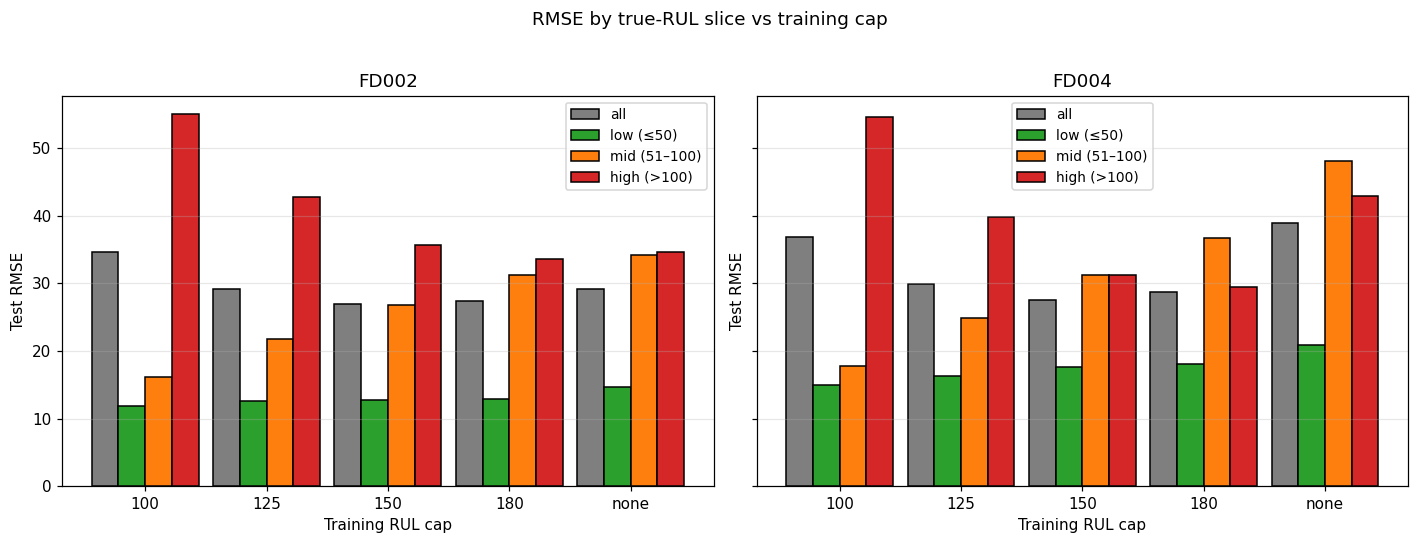

In [6]:
# ============ Plots ============
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
 
# 50. RMSE by cap, split into slices
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
cap_labels = [str(c) if c is not None else "none" for c in caps]
for ax, (ds, rs) in zip(axes, results.items()):
    x = np.arange(len(caps))
    w = 0.22
    ax.bar(x - 1.5*w, [r["RMSE_all"] for r in rs], w, label="all", color="tab:gray", edgecolor="black")
    ax.bar(x - 0.5*w, [r["RMSE_low"] for r in rs], w, label="low (≤50)", color="tab:green", edgecolor="black")
    ax.bar(x + 0.5*w, [r["RMSE_mid"] for r in rs], w, label="mid (51–100)", color="tab:orange", edgecolor="black")
    ax.bar(x + 1.5*w, [r["RMSE_high"] for r in rs], w, label="high (>100)", color="tab:red", edgecolor="black")
    ax.set_xticks(x); ax.set_xticklabels(cap_labels)
    ax.set_xlabel("Training RUL cap")
    ax.set_ylabel("Test RMSE")
    ax.set_title(ds)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis="y")
fig.suptitle("RMSE by true-RUL slice vs training cap", y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "50_cap_sweep_rmse.png", bbox_inches="tight")
plt.show()
plt.close()

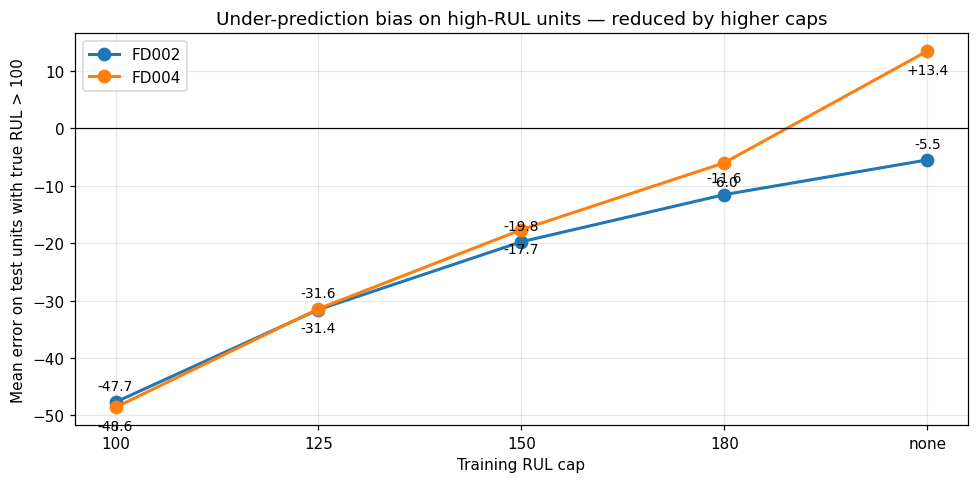

In [7]:
# 51. Bias on high-RUL slice vs cap
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(caps))
for i, (ds, rs) in enumerate(results.items()):
    bias_high = [r["bias_high"] for r in rs]
    ax.plot(x, bias_high, "o-", lw=2, ms=8, label=ds)
    for xi, v in zip(x, bias_high):
        ax.annotate(f"{v:+.1f}", (xi, v), xytext=(0, 8 if i == 0 else -15),
                    textcoords="offset points", ha="center", fontsize=9)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cap_labels)
ax.set_xlabel("Training RUL cap")
ax.set_ylabel("Mean error on test units with true RUL > 100")
ax.set_title("Under-prediction bias on high-RUL units — reduced by higher caps")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "51_bias_vs_cap.png", bbox_inches="tight")
plt.show()
plt.close()

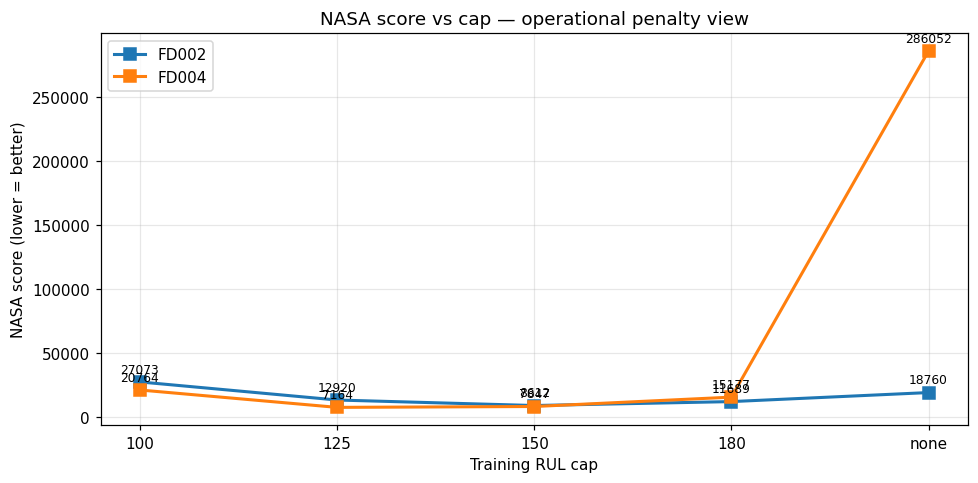

In [8]:
# 52. NASA score vs cap (asymmetric — rewards late/early differently)
fig, ax = plt.subplots(figsize=(9, 4.5))
for ds, rs in results.items():
    ax.plot(x, [r["NASA"] for r in rs], "s-", lw=2, ms=8, label=ds)
    for xi, r in zip(x, rs):
        ax.annotate(f"{r['NASA']:.0f}", (xi, r["NASA"]), xytext=(0, 6),
                    textcoords="offset points", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(cap_labels)
ax.set_xlabel("Training RUL cap")
ax.set_ylabel("NASA score (lower = better)")
ax.set_title("NASA score vs cap — operational penalty view")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "52_nasa_vs_cap.png", bbox_inches="tight")
plt.show()
plt.close()

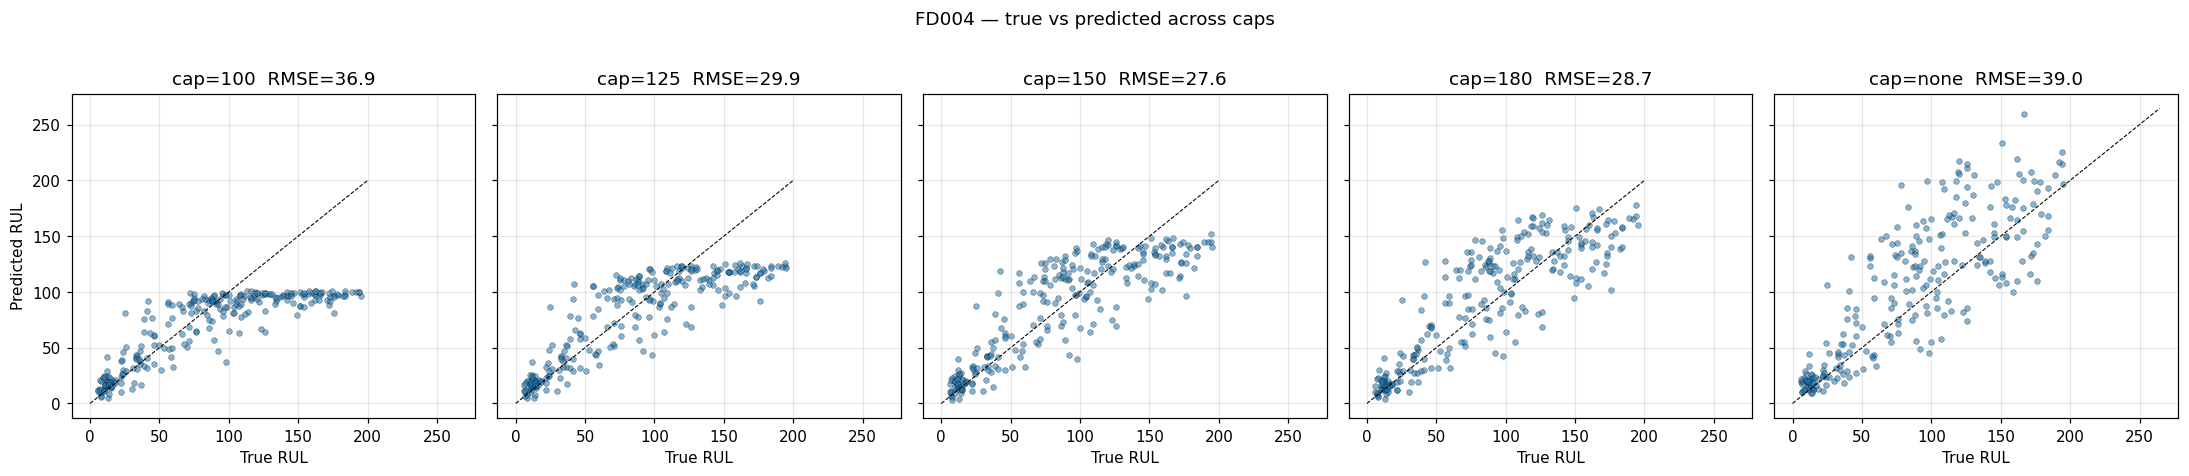

In [9]:
# 53. Scatter at best & worst cap (FD004)
fig, axes = plt.subplots(1, len(caps), figsize=(4 * len(caps), 4.2), sharex=True, sharey=True)
for ax, r in zip(axes, results["FD004"]):
    ax.scatter(r["true"], r["preds"], alpha=0.55, s=14, edgecolor="black", lw=0.3)
    lim = max(r["true"].max(), r["preds"].max()) + 5
    ax.plot([0, lim], [0, lim], "k--", lw=0.7)
    ax.set_title(f"cap={r['cap']}  RMSE={r['RMSE_all']:.1f}")
    ax.set_xlabel("True RUL")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Predicted RUL")
fig.suptitle("FD004 — true vs predicted across caps", y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "53_fd004_scatter_grid.png", bbox_inches="tight")
plt.show()
plt.close()